# Lag Compensator tutorial

- Prof. Hernán Felipe García Arias, PhD

- Faculty of Engineering - UdeA

- Control Systems

- 2026

# Design Procedure for the Phase Lag Compensator with Example in Python

In this tutorial, we introduce a phase lag compensator and explain a step-by-step procedure for designing its parameters. At the end, we give an example of designing a phase lag controller for a second-order system with a low phase margin. Before reading this tutorial, it is recommended to familiarize yourself with phase-lead controllers.



## The Effects of the Phase Lag Compensator

- **Increases Phase Margin & Provides Attenuation:**  
  A phase-lag compensator increases the phase margin and provides attenuation in the region near and above the gain crossover frequency (high-frequency range). Consequently, the relative stability of the system is improved.  
- **Decreases Gain Crossover Frequency & Bandwidth:**  
  The gain crossover frequency is decreased, which typically reduces the closed-loop system bandwidth. This usually increases rise time and settling time of the closed-loop response.  
- **Approximates a PI Controller:**  
  The phase-lag compensator behaves similarly to a Proportional–Integral (PI) controller.



_To illustrate the effect on the step response, consider the following system:_

$$
W(s) = \frac{10}{s(s + 1)}
$$

_With the designed lag compensator, the compensated open-loop transfer function becomes:_

$$
W_{\text{comp}}(s) = \underbrace{\frac{18.69\,s + 1}{306.7\,s + 1}}_{\text{phase lag compensator}} \;\times\; \frac{10}{s(s + 1)}
$$


The step responses of the compensated and uncompensated systems are shown in the figure below.

In [18]:
!pip install control

In [19]:
import control as ct
import matplotlib.pyplot as plt

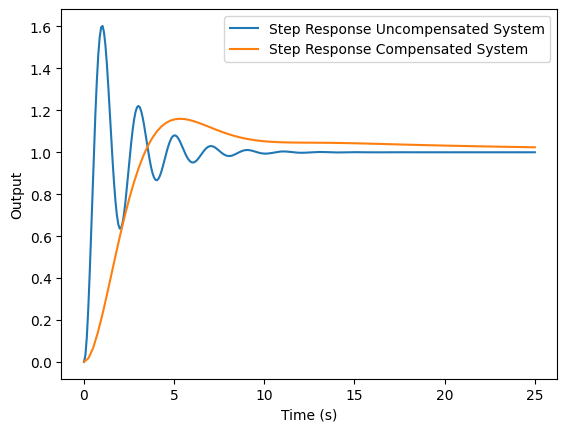

In [20]:
W = ct.tf([10],[1 ,1 ,0])
Gc = ct.tf([18.69,1],[306.7,1])
Wcomp=Gc*W

T1, y = ct.step_response(ct.feedback(W,1), T = 25)
T2, ycomp = ct.step_response(ct.feedback(Wcomp,1), T = 25)

plt.figure()
plt.plot(T1,y,label = 'Step Response Uncompensated System')
plt.plot(T2,ycomp,label = 'Step Response Compensated System')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()

We can observe that the phase lag compensator reduces the damping of the step response and makes the system more stable. However, the price we have to pay is the slower step response.

The figure below graphically illustrates the main idea of the phase lag compensator.

<img src = "https://aleksandarhaber.com/wp-content/uploads/2023/01/lag_compensator_explained-1-624x997.png">

## Equations and Graphs Describing the Phase Lag Compensator

The phase-lag compensator is described by the following equation:

$$
G_c(s) = \frac{1 + a\,T\,s}{1 + T\,s}, \qquad a < 1
$$

Obviously, it has a similar form to the phase-lead compensator, except for the crucial fact that $a < 1$. As a side effect, the phase-lag compensator introduces a small phase lag at low frequencies (well below the gain-crossover frequency), approximating a PI controller in behavior.

The main purpose of the lag compensator is to reduce the gain near the gain-crossover frequency without substantially altering the original system’s phase. By lowering the crossover frequency while keeping the phase nearly unchanged, the overall phase margin increases. The Bode diagram of the phase-lag compensator is shown below.

<img src = "https://aleksandarhaber.com/wp-content/uploads/2023/01/lag_compensator_sketch-624x510.png">

# Design Procedure for the Phase Lag Compensator

**Design specification and goal:**  
Achieve the phase margin (PM) of the compensated system that is greater than or equal to the minimum desired PM. Design the parameters $a$ and $T$ of the lag compensator:

$$
G_{c}(s) \;=\; \frac{1 + a\,T\,s}{1 + T\,s}\,, \qquad a < 1
$$



## STEP 1  
Plot the Bode diagram of the uncompensated open-loop system and identify its phase margin $\mathrm{PM}_{\mathrm{uncomp}}$. Under the assumption that the phase margin must be increased, choose a frequency on the phase plot—call it $\omega_{c}^{\mathrm{new}}$—where the phase margin of the compensated system would be $5$–$10^\circ$ larger than the desired PM. This $\omega_{c}^{\mathrm{new}}$ becomes the target gain-crossover frequency of the compensated system.



## STEP 2  
Bring the magnitude curve to $0\;\mathrm{dB}$ at $\omega_{c}^{\mathrm{new}}$. From the Bode magnitude plot, read the uncompensated system’s magnitude at $\omega_{c}^{\mathrm{new}}$, denoted $M(\omega_{c}^{\mathrm{new}})$. The lag compensator attenuates by $20\log_{10}(a)$, so impose

$$
\bigl|M(\omega_{c}^{\mathrm{new}})\bigr| = -\,20\log_{10}(a).
$$

Solving for $a$ gives

$$
a \;=\; 10^{-\lvert M(\omega_{c}^{\mathrm{new}})\rvert/20}.
$$



### STEP 3: Select the Time Constant $T$

The goal is to place the compensator’s corner frequency $1/(aT)$ significantly below the new gain-crossover frequency $\omega_c^{\text{new}}$, so that the lag’s phase lag does not affect the phase near $\omega_c^{\text{new}}$. A rule of thumb is to set $1/(aT)$ one decade below $\omega_c^{\text{new}}$. Thus:

$$
\frac{1}{aT} = \frac{\omega_c^{\text{new}}}{10}
$$

Solving for $T$ gives:

$$
T = \frac{10}{a\,\omega_c^{\text{new}}}
$$

*You may adjust this relationship if your system requires a different trade-off between bandwidth and lag-induced phase shift.*



### STEP 4: Validate and Iterate

1. **Plot** the Bode diagram of the compensated open-loop $G_c(s)\,W(s)$ using the computed $a$ and $T$.  
2. **Check** whether the phase margin and gain-crossover frequency meet your design specifications.  
3. **If not**, increase your previously chosen phase boost $\phi_m$ or tweak $T$ (e.g.\ move the corner frequency slightly) and repeat Steps 2–4 until the desired performance is achieved.




# Example of Designing a Phase-Lag Controller

**Problem:**  
Consider the following open-loop system:
$$
W(s) = \frac{10}{s\,(s + 1)}
$$
Design a lag compensator so that the phase margin of the compensated system is at least **50°**.



## Solution

We follow the general design procedure for a phase-lag controller:

### STEP 1: Analyze the Uncompensated System

1. **Plot the Bode diagram** of the open-loop transfer function $W(s)$.  
2. **Read off**:  
   - The uncompensated phase margin, $\mathrm{PM}_{\text{uncomp}}$.  
   - The gain cross-over frequency, $\omega_{gc,\text{uncomp}}$.  
3. **Compute the required phase boost**:
   $$
   \phi_m = \mathrm{PM}_{\text{desired}} - \mathrm{PM}_{\text{uncomp}} + \epsilon
           = 50^\circ - \mathrm{PM}_{\text{uncomp}} + 5^\circ.
   $$
4. (Optionally) add a small safety margin $\varepsilon$ to $\phi_m$ to account for non-idealities.

*Next: use $\phi_m$ to compute $a$ and $T$ in Steps 2–4.*


In [37]:
import control
import numpy as np
import matplotlib.pyplot as plt

from control.matlab import bode

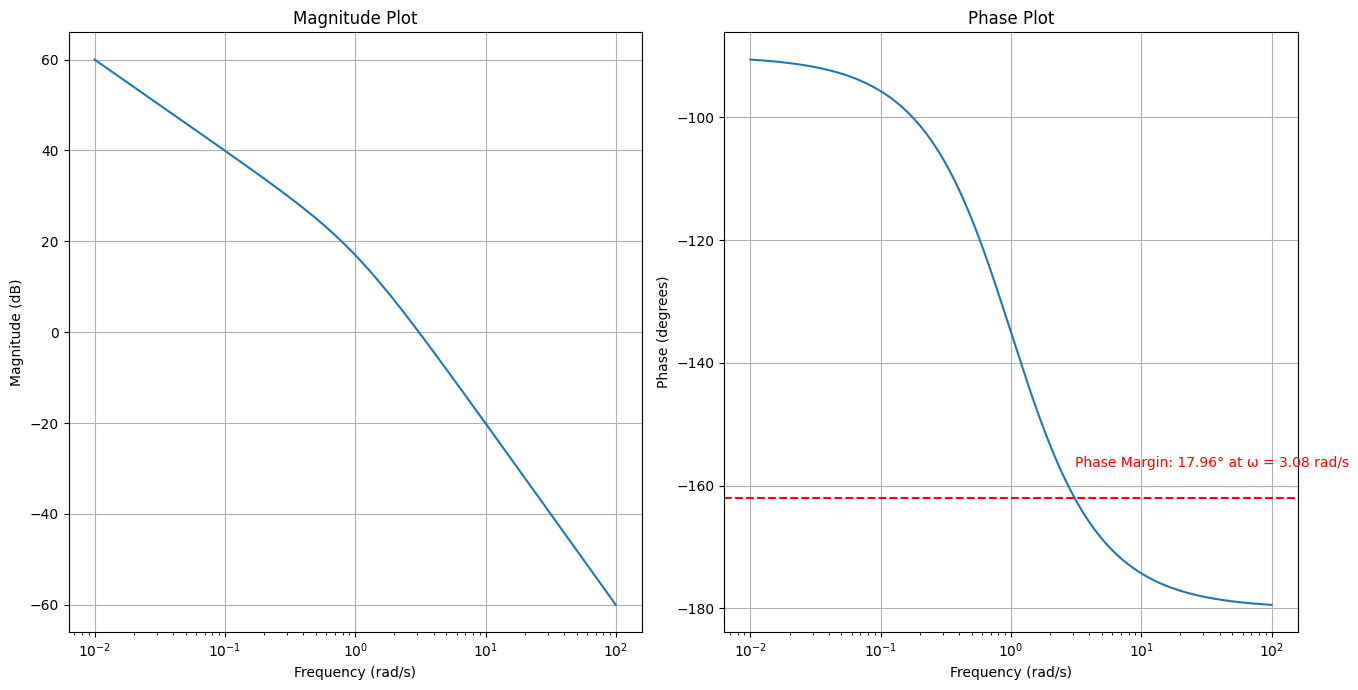

Phase Margin: 17.96° at ω = 3.08 rad/s


In [38]:
W = ct.tf(10,[1,1,0])
# Generate Bode plot with margins
mag, phase, omega = ct.bode_plot(W, plot=False, omega = [1e-2,1e2])

# Calculate margins for annotation
gm, pm, sm, gc = control.margin(W)
pm_deg = pm if pm >= 0 else pm + 360  # Ensure phase margin is positive for display

# Plotting
plt.figure(figsize=(14, 7))

## Magnitude plot
plt.subplot(1, 2, 1)
plt.semilogx(omega, 20*np.log10(mag))
plt.title('Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

## Phase plot
plt.subplot(1, 2, 2)
plt.semilogx(omega, np.rad2deg(phase))
plt.title('Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.grid(True)

# Display the phase margin on the plot
plt.axhline(y = -180 + pm_deg, color = 'r', linestyle = '--')
plt.text(gc, -180 + pm_deg + 5, f'Phase Margin: {pm_deg:.2f}° at ω = {gc:.2f} rad/s', color = 'red')

plt.tight_layout()
plt.show()

# Print the phase margin value
print(f"Phase Margin: {pm_deg:.2f}° at ω = {gc:.2f} rad/s")

The step response of the uncompensated closed-loop system is given in the figure below

Text(0, 0.5, 'Output')

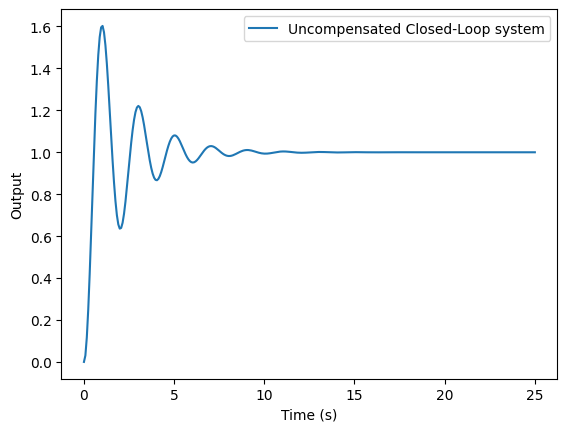

In [39]:
T, y = ct.step_response(ct.feedback(W,1), T = 25)
plt.figure()
plt.plot(T,y, label = 'Uncompensated Closed-Loop system')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Output')

By analyzing the results shown in these two figures, we can conclude that the phase margin does not satisfy the minimum requirement of 50 degrees. Also, from the step response, we can observe that the transient step response is undamped. Our goal is to increase the phase margin by using the phase lag controller. The two figures presented above are generated by using the following MATLAB code lines

From the Bode plot of the uncompensated system (see the figure above), we choose the gain cross-over frequency of the compensated system as

In [40]:
phase

array([-1.58079599, -1.58088861, -1.58098208, -1.58107641, -1.58117162,
       -1.58126771, -1.58136469, -1.58146257, -1.58156136, -1.58166106,
       -1.58176168, -1.58186324, -1.58196573, -1.58206917, -1.58217358,
       -1.58227895, -1.58238529, -1.58249262, -1.58260094, -1.58271027,
       -1.58282061, -1.58293197, -1.58304436, -1.58315779, -1.58327227,
       -1.58338782, -1.58350443, -1.58362212, -1.5837409 , -1.58386079,
       -1.58398178, -1.58410389, -1.58422713, -1.58435151, -1.58447705,
       -1.58460375, -1.58473162, -1.58486067, -1.58499092, -1.58512238,
       -1.58525505, -1.58538895, -1.58552409, -1.58566048, -1.58579813,
       -1.58593706, -1.58607728, -1.58621879, -1.58636161, -1.58650576,
       -1.58665124, -1.58679806, -1.58694625, -1.58709581, -1.58724675,
       -1.58739909, -1.58755284, -1.58770801, -1.58786462, -1.58802268,
       -1.5881822 , -1.5883432 , -1.58850569, -1.58866968, -1.58883519,
       -1.58900223, -1.58917082, -1.58934097, -1.58951269, -1.58

In [41]:
import numpy as np

# mag, phase, omega are 1D numpy arrays of the same length
# phase in degrees, mag in dB (or linear), omega in rad/s
PM_desired = 80 - pm + 5   # your target phase margin in degrees

# 1) Nearest‐neighbor approach
idx = np.argmin(np.abs(np.abs(np.rad2deg(phase)) - PM_desired))
omega_at_PM  = omega[idx]
mag_at_PM    = 20*np.log10(mag[idx])
print(f"Nearest ω at PM={PM_desired}°: ω ≃ {omega_at_PM:.3f} rad/s,  mag ≃ {mag_at_PM:.3f}")



Nearest ω at PM=67.03576408362864°: ω ≃ 0.010 rad/s,  mag ≃ 60.000


## STEP 2  
From the Bode plot of the uncompensated system, we observe that the required attenuation at $\omega_{c}^{\mathrm{new}}$ is $-24.3\ \mathrm{dB}$. Consequently, the magnitude ratio $a$ is  
$$
a \;=\; 10^{-\lvert M(\omega_{c}^{\mathrm{new}})\rvert /20}
      \;=\; 10^{-24.3/20}
      \;\approx\; 0.0610.
$$



## STEP 3  
We then select the time constant $T$ using  
$$
T \;=\; \frac{10}{a\,\omega_{c}^{\mathrm{new}}}
      \;=\; \frac{10}{0.0610 \times 0.535}
      \;\approx\; 306.65.
$$

The resulting lag compensator is therefore  
$$
G_{c}(s)
= \frac{18.69\,s + 1}{306.7\,s + 1}.
$$


In [42]:
float(omega_at_PM)

0.01

In [43]:
wc=float(omega_at_PM)
Mc=float(mag_at_PM)
a=np.pow(10.0,(-Mc/20.0))
T=10/(a*wc)
Gc=ct.tf([a*T ,1],[T ,1])
print(Gc)

<TransferFunction>: sys[78]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  1000 s + 1
  -----------
  1e+06 s + 1


**STEP 4:** The Bode plots of the compensated and uncompensated systems are shown in the figure below.

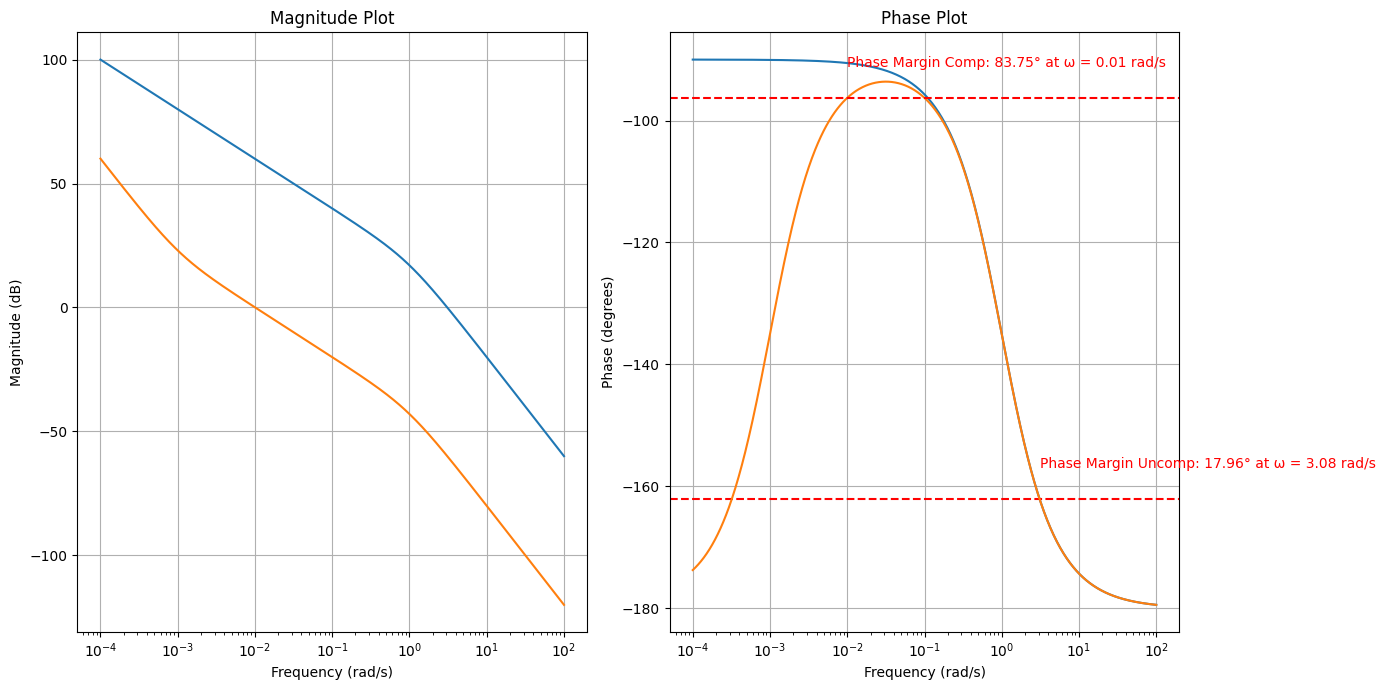

Phase Margin: 83.75° at ω = 0.01 rad/s


In [44]:
W = ct.tf(10,[1,1,0])
# Generate Bode plot with margins
mag, phase, omega = ct.bode_plot(W, plot=False, omega = [1e-4,1e2])

# Calculate margins for annotation
gm, pm, sm, gc = control.margin(W)
pm_deg = pm if pm >= 0 else pm + 360  # Ensure phase margin is positive for display

# Plotting
plt.figure(figsize=(14, 7))

## Magnitude plot
plt.subplot(1, 2, 1)
plt.semilogx(omega, 20*np.log10(mag))
plt.title('Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

## Phase plot
plt.subplot(1, 2, 2)
plt.semilogx(omega, np.rad2deg(phase))
plt.title('Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.grid(True)

# Display the phase margin on the plot
plt.axhline(y = -180 + pm_deg, color = 'r', linestyle = '--')
plt.text(gc, -180 + pm_deg + 5, f'Phase Margin Uncomp: {pm_deg:.2f}° at ω = {gc:.2f} rad/s', color = 'red')



#--
Wcomp = Gc*W
# Generate Bode plot with margins
mag, phase, omega = ct.bode_plot(Wcomp, plot=False, omega = [1e-4,1e2])

# Calculate margins for annotation
gm, pm, sm, gc = control.margin(Wcomp)
pm_deg = pm if pm >= 0 else pm + 360  # Ensure phase margin is positive for display



## Magnitude plot
plt.subplot(1, 2, 1)
plt.semilogx(omega, 20*np.log10(mag))
plt.title('Magnitude Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.grid(True)

## Phase plot
plt.subplot(1, 2, 2)
plt.semilogx(omega, np.rad2deg(phase))
plt.title('Phase Plot')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (degrees)')
plt.grid(True)

# Display the phase margin on the plot
plt.axhline(y = -180 + pm_deg, color = 'r', linestyle = '--')
plt.text(gc, -180 + pm_deg + 5, f'Phase Margin Comp: {pm_deg:.2f}° at ω = {gc:.2f} rad/s', color = 'red')

plt.tight_layout()
plt.show()

# Print the phase margin value
print(f"Phase Margin: {pm_deg:.2f}° at ω = {gc:.2f} rad/s")

We can observe that the compensated system achieves the required phase margin, and the gain cross-over frequency is close to the estimated one. The figure below shows the step responses of the closed-loop compensated and uncompensated systems.

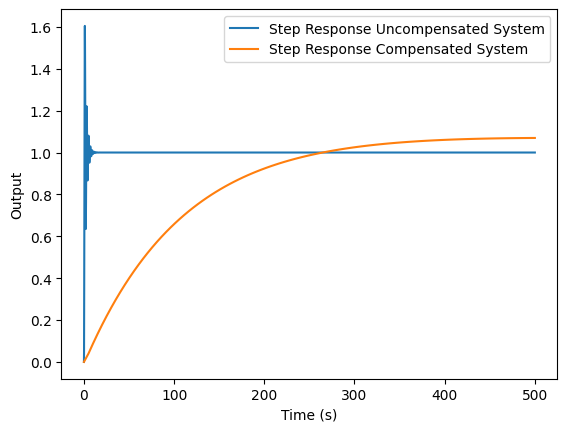

In [45]:
T1, y = ct.step_response(ct.feedback(W,1), T = 500)
T2, ycomp = ct.step_response(ct.feedback(Wcomp,1), T = 500)

plt.figure()
plt.plot(T1,y,label = 'Step Response Uncompensated System')
plt.plot(T2,ycomp,label = 'Step Response Compensated System')
plt.xlabel('Time (s)')
plt.ylabel('Output')
plt.legend()

We can observe that the damping is attenuated, however, at the expense of the slower response. The system will eventually settle in the desired position of 1.

# 🛠️ Taller: Diseño de Compensadores Adelanto, Atraso y Adelanto–Atraso mediante Diagramas de Bode

En este taller diseñarás **compensadores adelanto, atraso y adelanto–atraso** empleando exclusivamente **diagramas de Bode** y análisis en frecuencia. El objetivo es modificar el **margen de fase (PM)**, el **margen de ganancia (GM)** y la **frecuencia de cruce de ganancia** de dos sistemas de control para cumplir especificaciones dinámicas deseadas.



# 1. Sistema A: Planta de primer orden de un motor DC (modelo FOPDT sin retardo)

La dinámica de velocidad de un motor DC puede aproximarse como un sistema de **primer orden**:

$$
G_A(s) = \frac{K_m}{\tau_m s + 1}.
$$

Considera control por realimentación unitaria y inicialmente solo un controlador proporcional:
$$
C(s) = K_c.
$$

## 🎯 Objetivos de diseño (en frecuencia)
Para este sistema se desea lograr:

1. Un **margen de fase deseado**:
   $$
   PM^\star \ge 50^\circ,
   $$
2. Una **frecuencia de cruce de ganancia** mayor que la original para obtener una respuesta más rápida,
3. Estabilidad robusta (GM adecuado).



## 🔍 Actividad 1: Análisis sin compensador
1. Obtenga el Bode de:
   $$
   L(s) = C(s)G_A(s) = K_c\,G_A(s).
   $$
2. Determine:
   - Frecuencia de cruce de ganancia $ \omega_{gc} $,
   - Margen de fase actual $ PM $,
   - Margen de ganancia $ GM $.
3. Concluya si el sistema cumple o no el especificado $ PM^\star $.



## 🔧 Actividad 2: Diseño de un **compensador adelanto (lead)** en Bode

Objetivo: **incrementar el margen de fase** para alcanzar $PM^\star$ y aumentar la rapidez del sistema.

El compensador adelanto tiene la forma:

$$
C_{\text{lead}}(s) = K \frac{s + z_c}{s + p_c},\quad z_c > p_c.
$$

### Pasos para el diseño:
1. Determine la **frecuencia donde desea lograr el nuevo PM**, típicamente cerca de la nueva frecuencia de cruce.
2. Calcule el **ángulo extra** necesario:
   $$
   \phi_{\text{add}} = PM^\star - PM_{\text{actual}} + 5^\circ \text{ (margen adicional)}.
   $$
3. El máximo adelanto de fase que entrega el compensador es:
   $$
   \phi_{\max} = \sin^{-1}\left(\frac{\alpha - 1}{\alpha + 1}\right),
   \quad \alpha = \frac{z_c}{p_c}.
   $$
4. Seleccione $ \alpha $ y determine:
   $$
   \omega_m = \frac{1}{\sqrt{p_c z_c}},
   $$
   que es la frecuencia a la que ocurre el máximo adelanto.
5. Verifique en Bode que la nueva curva cumpla:
   - $PM \ge PM^\star$,
   - frecuencia de cruce mayor,
   - estabilidad adecuada.



## 🔧 Actividad 3: Diseño del **compensador atraso (lag)**

Objetivo: **mejorar el margen de ganancia y el comportamiento estacionario**, aumentando la ganancia de baja frecuencia sin afectar significativamente el PM.

La forma del compensador es:

$$
C_{\text{lag}}(s) = K \frac{s + z_l}{s + p_l},\quad z_l < p_l.
$$

Pasos:

1. Seleccione el ratio:
   $$
   \beta = \frac{p_l}{z_l} > 1,
   $$
   para incrementar la ganancia DC.
2. Ubique $z_l$ y $p_l$ de forma que la frecuencia de cruce **no cambie demasiado**.
3. Verifique en Bode:
   - mejor ganancia en bajas frecuencias,
   - PM casi inalterado,
   - incremento del GM si es necesario.



## 🔧 Actividad 4: Diseño del **compensador adelanto–atraso (lead–lag)**

Objetivo: lograr un compromiso entre:
- **más rapidez y mejor PM** (parte adelanto),
- **mejor rechazo al error estacionario** (parte atraso).

Compensador general:

$$
C_{\text{lead-lag}}(s) =
K\,\frac{(s+z_{c1})(s+z_{c2})}{(s+p_{c1})(s+p_{c2})},
$$
con:
- $ z_{c1} > p_{c1} $ (adelanto),
- $ z_{c2} < p_{c2} $ (atraso).

El diseño se basa en:
1. Usar primero la parte *lead* para alcanzar el PM deseado.  
2. Usar luego la parte *lag* para refinar ganancia en DC sin alterar la dinámica transitoria.



# 2. Sistema B: Sistema de segundo orden con sobreimpulso inicial del 25%

Considere:

$$
G_B(s) = \frac{\omega_n^2}{s^2 + 2\zeta_0 \omega_n s + \omega_n^2},
$$

donde el sobreimpulso inicial es:
$$
M_p \approx 25\%.
$$

Este sistema tendrá un margen de fase inicial asociado a ese valor de amortiguamiento.



## 🎯 Objetivos de diseño para el Sistema B

Se desea diseñar **tres compensadores diferentes** (adelanto, atraso y adelanto–atraso) de forma que el sistema modificado cumpla:

$$
M_p < 7\% \quad \Longleftrightarrow \quad
PM^\star \approx 55^\circ \text{ a } 65^\circ.
$$

La relación entre $M_p$ y $PM$ es un indicador útil, pues mayor PM implica mayor amortiguamiento y menor sobreimpulso.



## 🔍 Actividad 5: Análisis del sistema sin compensar

1. Obtenga el **Bode** del sistema.
2. Determine el **margen de fase actual $PM$**.
3. Compare con el objetivo:
   $$
   PM^\star \in [55^\circ, 65^\circ].
   $$
4. Concluya si el sistema necesita aumentar o disminuir el PM.



## 🔧 Actividad 6: Diseño del compensador **adelanto** para cumplir $PM^\star$

1. Determine el ángulo adicional requerido:
   $$
   \phi_{\text{add}} = PM^\star - PM_{\text{actual}}.
   $$
2. Diseñe $C_{\text{lead}}(s)$ con la metodología presentada en el Sistema A.
3. Verifique:
   - Nuevo PM,
   - Nuevas frecuencias de cruce,
   - GM resultante.



## 🔧 Actividad 7: Diseño del compensador **atraso**

Objetivo: mejorar el error estacionario **sin alterar el PM** logrado con el compensador adelanto.

Pasos:
1. Defina la mejora en ganancia DC deseada.
2. Diseñe $z_l$ y $p_l$ de forma que:
   - el cambio de fase sea pequeño en la nueva frecuencia de cruce,
   - el GM mejore si hace falta.
3. Verifique en Bode:
   - Ganancia DC mayor,
   - PM casi inalterado.



## 🔧 Actividad 8: Diseño del compensador **adelanto–atraso**

Este compensador se diseña cuando se necesita simultáneamente:
- aumentar PM,
- mejorar precisión en régimen permanente,
- mantener control sobre la frecuencia de cruce.

Integre:
- Un par adelanto para cumplir $PM^\star$.
- Un par atraso para ajustar la ganancia DC.

Verifique mediante Bode:
- PM final,
- GM final,
- banda ancha del sistema,
- impacto en la frecuencia de cruce.



## 📌 Entrega sugerida

Para **cada sistema (A y B)** entregue:

- Bode del sistema sin compensar, con compensador adelanto, atraso y adelanto–atraso.  
- Valores comparativos de:
  - $PM$, $GM$,
  - $ \omega_{gc} $,
  - ganancia DC,
  - ancho de banda.
- Explicación de cómo el compensador desplaza los márgenes.  
- Respuestas temporales comparativas antes y después del compensador.  
- Conclusión sobre cuál compensador cumple mejor la especificación.

